<a href="https://colab.research.google.com/github/nitish36200/Projects/blob/main/ML_Project/Future_sale_prediction1/ml_project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
#importing all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


from itertools import product
from collections import Counter
from sklearn.cluster import k_means
from sklearn.preprocessing import LabelEncoder


In [27]:
train = pd.read_csv("sales_train.csv",parse_dates=['date'])

In [28]:
test= pd.read_csv("test.csv")

In [29]:
shop= pd.read_csv("shops.csv")


In [30]:
items = pd.read_csv("items.csv")

In [31]:
item_categories= pd.read_csv("item_categories.csv")

In [32]:
train.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0


In [33]:
test.head()

,ID,shop_id,item_id
0,0,5,5037
1,1,5,5320
2,2,5,5233
3,3,5,5232
4,4,5,5268


In [34]:
shop.head()

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


In [35]:
items.head()

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


In [36]:
item_categories.head()

,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


Exploring the Data

In [37]:
print("No. of shops: ", len(shop))
print("No. ofnumber of categories:", len(item_categories))
print("No. of items:", len(items))
print("No. of train:",len(train))
print("No. of test:", len(test))

No. of shops:  60
No. ofnumber of categories: 84
No. of items: 22170
No. of train: 2935849
No. of test: 214200


In [38]:
shop.nunique()

,0
shop_name,60
shop_id,60


In [39]:
items.nunique()

,0
item_name,22170
item_id,22170
item_category_id,84


In [40]:
item_categories.nunique()

,0
item_category_name,84
item_category_id,84


In [41]:
train.describe()

,date_block_num,shop_id,item_id,item_price,item_cnt_day
count,2.935849e+06,2.935849e+06,2.935849e+06,2.935849e+06,2.935849e+06
mean,1.456991e+01,3.300173e+01,1.019723e+04,8.908532e+02,1.242641e+00
std,9.422988e+00,1.622697e+01,6.324297e+03,1.729800e+03,2.618834e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-2.200000e+01
25%,7.000000e+00,2.200000e+01,4.476000e+03,2.490000e+02,1.000000e+00
50%,1.400000e+01,3.100000e+01,9.343000e+03,3.990000e+02,1.000000e+00
75%,2.300000e+01,4.700000e+01,1.568400e+04,9.990000e+02,1.000000e+00
max,3.300000e+01,5.900000e+01,2.216900e+04,3.079800e+05,2.169000e+03


In [42]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   date            object 
 1   date_block_num  int64  
 2   shop_id         int64  
 3   item_id         int64  
 4   item_price      float64
 5   item_cnt_day    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 134.4+ MB


In [43]:
#Missing Values
train.isnull().sum()


,0
date,0
date_block_num,0
shop_id,0
item_id,0
item_price,0
item_cnt_day,0


Data Visualization

In [47]:
px.histogram(items[['item_category_id','item_id']], x='item_category_id',title='Distribution of items in category').update_xaxes(dtick=True)


In [54]:
total_shop_sale=pd.DataFrame(train.groupby('shop_id')['item_cnt_day'].sum().sort_values(ascending=False))

In [53]:
total_shop_sale

(<module 'pandas' from '/usr/local/lib/python3.13/dist-packages/pandas/__init__.py'>,
          item_cnt_day
 shop_id              
 31           310777.0
 25           241920.0
 54           185790.0
 28           184557.0
 42           144934.0
 57           141107.0
 27           136657.0
 6            100489.0
 58            81734.0
 46            78990.0
 56            78079.0
 50            76238.0
 12            73478.0
 19            73455.0
 15            71201.0
 35            69016.0
 21            68560.0
 26            67890.0
 47            67637.0
 7             67058.0
 18            65486.0
 24            63886.0
 55            63388.0
 53            61657.0
 16            61633.0
 30            60828.0
 22            60230.0
 29            58713.0
 38            53886.0
 43            50608.0
 52            49744.0
 41            49324.0
 59            48993.0
 51            48767.0
 14            46375.0
 37            46256.0
 44            44938.0
 4             43

In [59]:
shops_daily_sales = pd.DataFrame(train.groupby(['date','shop_id'])[['item_cnt_day','item_price']].sum().reset_index())


In [60]:
shops_daily_sales

,date,shop_id,item_cnt_day,item_price
0,01.01.2013,2,24.0,31287.000000
1,01.01.2013,7,89.0,58595.000000
2,01.01.2013,8,50.0,43118.000000
3,01.01.2013,13,31.0,5804.000000
4,01.01.2013,14,66.0,43673.000000
...,...,...,...,...
47223,31.12.2014,55,174.0,44325.000000
47224,31.12.2014,56,209.0,186611.895000
47225,31.12.2014,57,672.0,527943.797000
47226,31.12.2014,58,457.0,364652.861548


In [65]:
item_prices = pd.DataFrame(train.groupby(['item_id','item_price']).first()).reset_index()[['item_id','item_price']]


IN data sets some outlier in item_orice and item_count

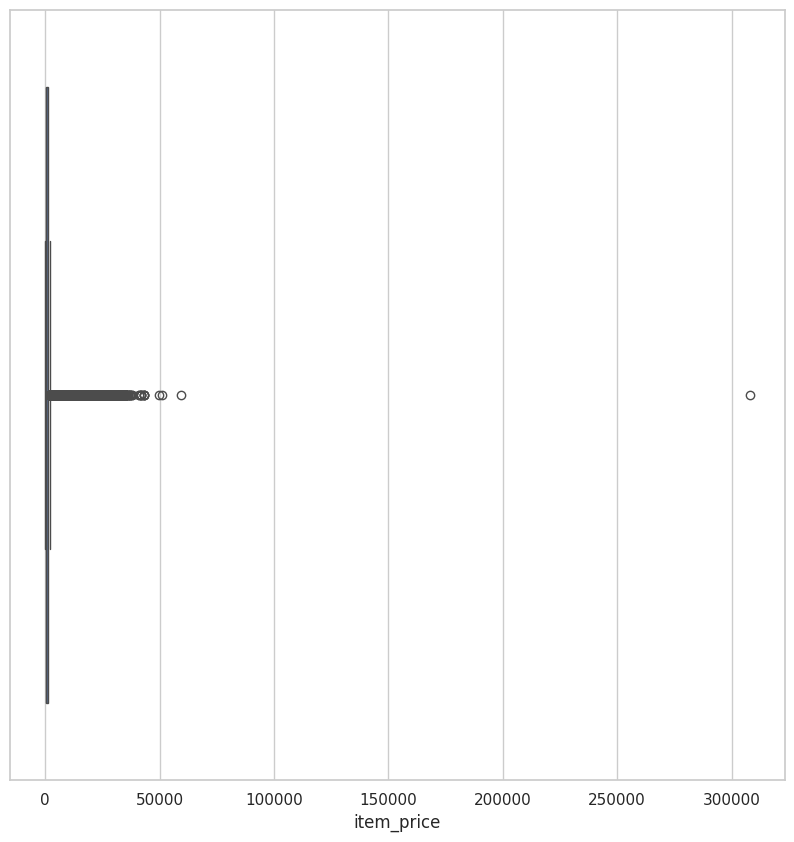

In [74]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,10))
sns.boxplot(x=train['item_price'])
plt.show()

<Axes: xlabel='item_cnt_day'>

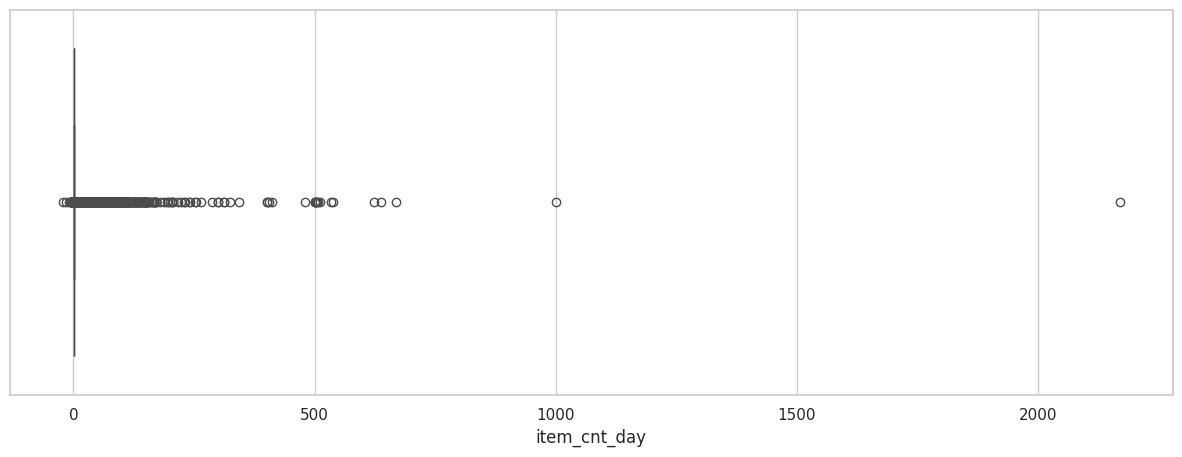

In [76]:
plt.figure(figsize=(15,5))
sns.boxplot(x=train['item_cnt_day'])

In [77]:
#Removing some outliers
train= train[train.item_price<100000]
train= train[train.item_cnt_day<1001]

<Axes: xlabel='item_cnt_day'>

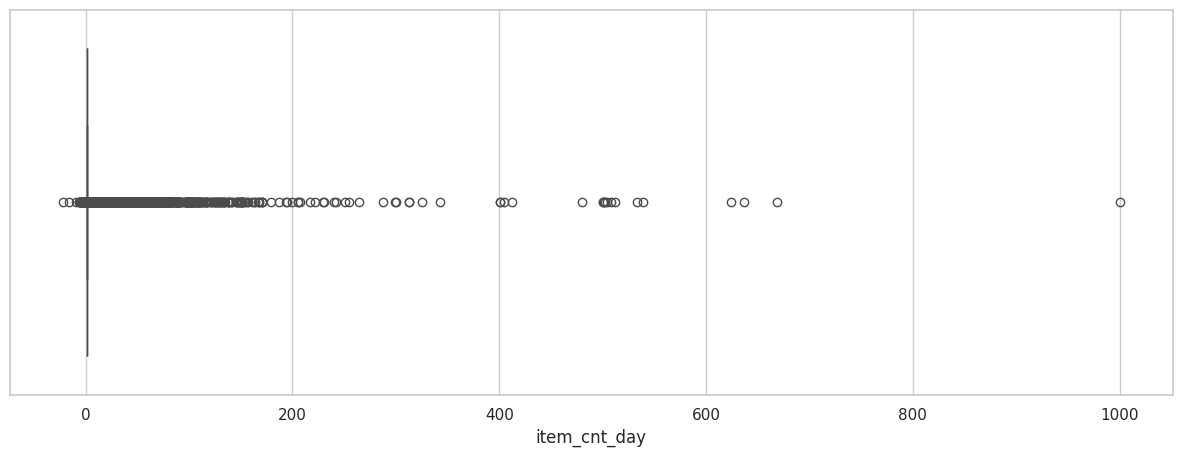

In [79]:
#After removing some outlier from item_cnt_day
plt.figure(figsize=(15,5))
sns.boxplot(x=train.item_cnt_day)

In [81]:
#checking -ve value in price in items
train.min(numeric_only=True)

,0
date_block_num,0.0
shop_id,0.0
item_id,0.0
item_price,-1.0
item_cnt_day,-22.0


In [82]:
#removing negative values from item_price and item_cnt_Day
train[train.item_price<0]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
484683,15.05.2013,4,32,2973,-1.0,1.0


In [83]:
#removing negative values from item_price and item_cnt_Day
train[train.item_cnt_day<0]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
2,05.01.2013,0,25,2552,899.0,-1.0
148,23.01.2013,0,25,2321,999.0,-1.0
175,07.01.2013,0,25,2199,1449.0,-1.0
807,02.01.2013,0,25,2330,599.0,-1.0
1041,13.01.2013,0,25,5034,1989.0,-1.0
...,...,...,...,...,...,...
2934243,26.10.2015,33,25,3917,449.0,-1.0
2934462,18.10.2015,33,25,4896,6398.0,-1.0
2935263,05.10.2015,33,25,10039,249.0,-1.0
2935643,16.10.2015,33,25,7893,2990.0,-1.0


In [89]:
negprice=train[train.item_price<0].index
negcnt = train[train.item_cnt_day<0].index
negprice
negcnt

Index([      2,     148,     175,     807,    1041,    1193,    1674,    1825,
          2411,    3216,
       ...
       2932589, 2932636, 2932721, 2933448, 2933712, 2934243, 2934462, 2935263,
       2935643, 2935779],
      dtype='int64', length=7356)

In [94]:
(train['item_price'] < 0).any()

np.True_

Making negative value null and imputing them using sklearn KNNImpiter